# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

**Chapter 12: Time Series Models**

Notebook 12.1: ARIMA Models for Financial Forecasting

Version: 3.0

Last revised: 2026-07-28

**Walk-forward evaluation of ARIMA on SPY daily returns, and the VIX counterexample that shows where the model does work.**

> Save a copy to your own Drive before running: File > Save a copy in Drive. Edits to the shared notebook are not preserved.



---


ARIMA (AutoRegressive Integrated Moving Average) is the most commonly cited time-series model in online trading tutorials. Search GitHub for "stock price prediction ARIMA" and you will find thousands of repositories. Search for ones that actually work in live trading and you will find none.

This notebook applies ARIMA to financial data using the only methodology that matters for evaluating a forecasting model as a trading signal: walk-forward one-step-ahead forecasting. Most online examples use a single train/test split and call `.forecast(steps=252)`, which is multi-step forecasting with compounding errors and is useless for daily trading decisions. We will do it properly.

Sections 1 through 5 apply ARIMA to SPY daily returns and convert the forecast into a trading signal. The result will be underwhelming, and that is the point. Section 6 applies the same framework to the VIX, where ARIMA's assumptions (stationarity and meaningful autocorrelation) are actually met. The contrast tells us something important: ARIMA is not a bad model. It is simply the wrong model for predicting daily equity returns.

**What we will cover:**

- Stationarity testing (ADF) and why we model returns, not prices
- ACF/PACF analysis to assess autocorrelation structure
- Automated model order selection with `pmdarima`
- Walk-forward one-step-ahead forecasting (the correct methodology)
- Converting forecasts to a trading signal and evaluating with standard performance metrics
- Comparing ARIMA on SPY returns vs. VIX to understand when the model works and when it does not

In [ ]:
# ============================================================
# Setup and Configuration
# ============================================================
# We do not pin versions here because Colab's pre-installed
# numpy and scipy versions change frequently, and compiled
# extensions in pmdarima and statsmodels must match them.
# Instead, we install the latest compatible versions and print
# them below for reproducibility. If Colab's environment changes
# in the future, the parquet data caching pattern ensures the
# notebook still runs even if yfinance breaks.
# ============================================================

!pip install pmdarima statsmodels yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
import warnings
import time
from pathlib import Path
import os

warnings.filterwarnings('ignore')

# ── Parameters ──────────────────────────────────────────────
# All configurable values in one place. Change these to
# re-run the entire notebook with different assumptions.
# ────────────────────────────────────────────────────────────

TICKER = 'SPY'
VIX_TICKER = '^VIX'
SAFE_ASSET = 'BIL'
START_DATE = '2005-01-01'
END_DATE = '2025-12-31'

# Walk-forward parameters
TRAIN_WINDOW = 504          # Rolling training window: ~2 years of trading days
FORECAST_HORIZON = 1        # One-step-ahead (the only defensible approach)

# Evaluation parameters
RISK_FREE_RATE = 0.0        # For Sharpe ratio calculation
TRADING_DAYS_PER_YEAR = 252

# Data caching
# Data caching
CACHE_FILE = 'ch12_nb01_prices.parquet'

# Print library versions for reproducibility
print(f"numpy:       {np.__version__}")
print(f"pandas:      {pd.__version__}")
print(f"statsmodels: {sm.__version__}")
print(f"pmdarima:    {pm.__version__}")
print(f"yfinance:    {yf.__version__}")

numpy:       2.0.2
pandas:      2.2.2
statsmodels: 0.14.6
pmdarima:    2.1.1
yfinance:    0.2.66


## Section 1: Setup and Data Loading

We need three instruments for this notebook:

- **SPY:** the S&P 500 ETF whose daily returns we will attempt to forecast
- **BIL:** short-term Treasury ETF, our risk-free alternative when the model forecasts a negative return
- **VIX:** the CBOE Volatility Index, used in Section 6 to demonstrate where ARIMA actually works

We download via `yfinance` and cache to parquet files. If the parquet files already exist, we load from cache. This protects against future `yfinance` API changes and avoids hitting Yahoo's servers on every run.

In [ ]:
# ============================================================
# Download and Cache Data
# ============================================================
# Download once, cache to parquet, load from cache thereafter.
# If yfinance breaks in the future, readers can place their
# own parquet files in the colab folder and skip this step.
# ============================================================

tickers = [TICKER, SAFE_ASSET, VIX_TICKER]

if os.path.exists(CACHE_FILE):
    print(f"Loading cached data from {CACHE_FILE}")
    df_prices = pd.read_parquet(CACHE_FILE)
else:
    print(f"Downloading {tickers} from yfinance...")
    df_prices = yf.download(tickers, start=START_DATE, end=END_DATE)['Close']

    # yfinance returns ^VIX with the caret in the column name.
    # Rename for cleaner references throughout the notebook.
    df_prices.columns = [c.replace('^', '') for c in df_prices.columns]
    df_prices = df_prices.dropna()
    df_prices.to_parquet(CACHE_FILE)
    print(f"Saved to {CACHE_FILE}")

# Calculate SPY daily log returns (the series we will model)
df_prices['SPY_log_return'] = np.log(df_prices['SPY'] / df_prices['SPY'].shift(1))
df_prices = df_prices.dropna()

# Summary
print(f"\nDate range: {df_prices.index[0].strftime('%Y-%m-%d')} to "
      f"{df_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(df_prices):,}")
print(f"\nFirst 5 rows:")
print(df_prices.head())
print(f"\nLast 5 rows:")
print(df_prices.tail())

[*********************100%***********************]  3 of 3 completed


Saved to ch12_nb01_prices.parquet

Date range: 2007-05-31 to 2025-12-30
Trading days: 4,677

First 5 rows:
                  BIL         SPY    VIX  SPY_log_return
Date                                                    
2007-05-31  70.587540  107.652191  13.05       -0.001044
2007-06-01  70.602936  108.185867  12.78        0.004945
2007-06-04  70.618378  108.199928  13.29        0.000130
2007-06-05  70.618378  107.771591  13.63       -0.003967
2007-06-06  70.649200  106.613060  14.87       -0.010808

Last 5 rows:
                  BIL         SPY    VIX  SPY_log_return
Date                                                    
2025-12-23  89.729309  684.323303  14.00        0.004560
2025-12-24  89.758781  686.730530  13.47        0.003512
2025-12-26  89.788269  686.660889  13.60       -0.000101
2025-12-29  89.788269  684.213867  14.20       -0.003570
2025-12-30  89.798103  683.378296  14.33       -0.001222


We have 4,677 trading days of data from May 2007 through December 2025, roughly 18.5 years. The start date is driven by BIL's inception (May 2007), not by SPY or VIX, which both have longer histories. This is a common constraint in multi-asset notebooks: the shortest history dictates the sample.

The `SPY_log_return` column is what we will attempt to forecast with ARIMA. We use log returns rather than simple returns for three reasons:

- **Additivity:** log returns sum across time periods, which simplifies cumulative return calculations
- **Approximate normality:** log returns are closer to normally distributed than simple returns, satisfying one of ARIMA's implicit assumptions
- **Stationarity:** log returns are stationary (their mean and variance do not drift over time), which is a hard requirement for ARIMA. Raw prices are non-stationary, trending upward over the long run. Fitting ARIMA to prices is the first and most common mistake in online tutorials.



### Seeing stationarity before testing for it

The ADF test returns a p-value, and a p-value is easy to accept without understanding what it measured. Before running it, we plot the two series side by side so you can see the property the test is checking. Watch the vertical axis on each panel, and ask yourself what "the average value of this series" would even mean for each one.

[*********************100%***********************]  1 of 1 completed


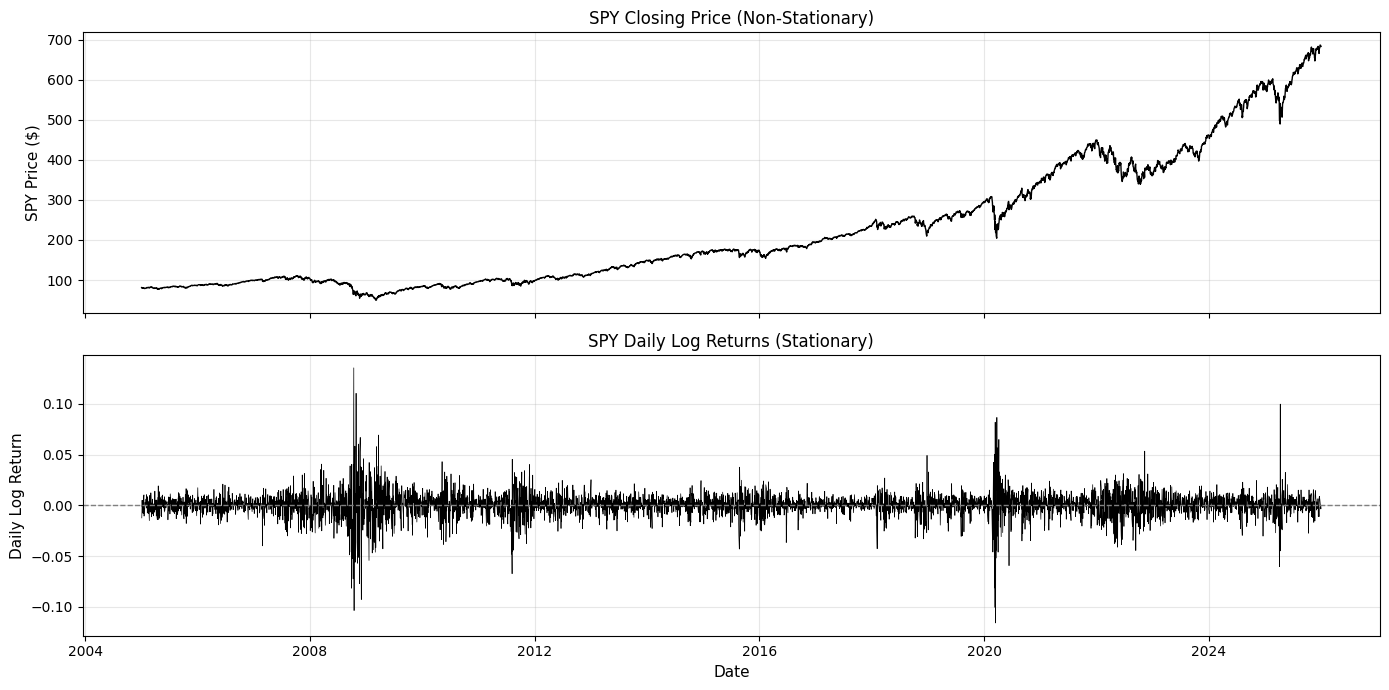

Mean SPY price, 2005-2010: $86.73
Mean SPY price, 2020-2025: $438.38
Mean daily log return, 2005-2010: 0.000109
Mean daily log return, 2020-2025: 0.000561


In [ ]:
# ============================================================
# Prices vs. Returns: What Stationarity Looks Like
# ============================================================
# Before running a formal stationarity test, it helps to see
# what the test is actually measuring. A stationary series has
# a mean and variance that hold steady no matter which window
# you measure them over. A non-stationary series does not.
#
# We download SPY on its own here rather than using the cached
# parquet, because that file is limited by BIL's 2007 inception
# and we want the full period from 2005.
#
# Grayscale-safe: both panels use black lines with a grey
# reference line, no color encoding.
# ============================================================

df_spy_only = yf.download('SPY', start='2005-01-01', end='2025-12-31')['Close']
df_spy_only = df_spy_only.squeeze()
spy_log_ret = np.log(df_spy_only / df_spy_only.shift(1)).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- Top panel: price level ---
axes[0].plot(df_spy_only.index, df_spy_only.values,
             color='black', linewidth=1.0)
axes[0].set_title('SPY Closing Price (Non-Stationary)', fontsize=12)
axes[0].set_ylabel('SPY Price ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Bottom panel: daily log returns ---
# The zero line is the visual anchor. The price panel has no
# equivalent, which is the entire point of the comparison.
axes[1].plot(spy_log_ret.index, spy_log_ret.values,
             color='black', linewidth=0.5)
axes[1].axhline(y=0, color='grey', linestyle='--', linewidth=1.0)
axes[1].set_title('SPY Daily Log Returns (Stationary)', fontsize=12)
axes[1].set_ylabel('Daily Log Return', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the window-dependence that the top panel shows visually
print(f"Mean SPY price, 2005-2010: ${df_spy_only.loc['2005':'2010'].mean():.2f}")
print(f"Mean SPY price, 2020-2025: ${df_spy_only.loc['2020':'2025'].mean():.2f}")
print(f"Mean daily log return, 2005-2010: {spy_log_ret.loc['2005':'2010'].mean():.6f}")
print(f"Mean daily log return, 2020-2025: {spy_log_ret.loc['2020':'2025'].mean():.6f}")

Before we fit any model, we need to confirm that stationarity claim, first visually and then with a formal test.

In [ ]:
# ============================================================
# Stationarity Testing: Augmented Dickey-Fuller (ADF)
# ============================================================
# The ADF test checks whether a time series has a unit root,
# which is a statistical way of asking: does this series
# wander randomly, or does it revert to a stable mean?
#
# - Null hypothesis: the series has a unit root (non-stationary)
# - Alternative: the series is stationary
# - If p-value < 0.05, we reject the null and conclude stationary
#
# We test both SPY prices and SPY log returns to show the
# contrast. ARIMA requires stationary input. Fitting it to
# non-stationary prices is methodologically wrong, and this
# test makes that concrete.
# ============================================================

def run_adf_test(series, series_name):
    """Run ADF test and print a clean summary."""
    result = adfuller(series.dropna(), autolag='AIC')

    print(f"ADF Test: {series_name}")
    print(f"  Test Statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.6f}")
    print(f"  Lags Used:      {result[2]}")
    print(f"  Observations:   {result[3]}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")

    # Plain-language interpretation
    if result[1] < 0.05:
        print(f"  Conclusion: STATIONARY (p < 0.05, reject unit root)\n")
    else:
        print(f"  Conclusion: NON-STATIONARY (p >= 0.05, cannot reject unit root)\n")

# Test SPY prices (expect: non-stationary)
print("=" * 55)
run_adf_test(df_prices['SPY'], 'SPY Closing Prices')

# Test SPY log returns (expect: stationary)
print("=" * 55)
run_adf_test(df_prices['SPY_log_return'], 'SPY Daily Log Returns')

ADF Test: SPY Closing Prices
  Test Statistic: 2.6714
  p-value:        0.999085
  Lags Used:      29
  Observations:   4647
  Critical Values:
    1%: -3.4318
    5%: -2.8622
    10%: -2.5671
  Conclusion: NON-STATIONARY (p >= 0.05, cannot reject unit root)

ADF Test: SPY Daily Log Returns
  Test Statistic: -17.3162
  p-value:        0.000000
  Lags Used:      15
  Observations:   4661
  Critical Values:
    1%: -3.4318
    5%: -2.8622
    10%: -2.5671
  Conclusion: STATIONARY (p < 0.05, reject unit root)



The results could not be clearer:

- **SPY prices:** test statistic of +2.67, p-value of 0.999. Not only do we fail to reject the unit root, the test statistic is positive, meaning prices are actively trending away from any fixed mean. ARIMA on this series would be fitting a model to data that violates its core assumption.
- **SPY log returns:** test statistic of -17.32, p-value effectively zero. Stationary beyond any reasonable doubt. This is the series ARIMA can work with.

This is the first error we flagged in online tutorials: fitting ARIMA (or Prophet) to price levels instead of returns. The ADF test makes the mistake quantifiable rather than theoretical. Prices wander; returns do not.

Next we examine the autocorrelation structure of log returns. Even though the series is stationary, ARIMA can only help if there is serial dependence to exploit.

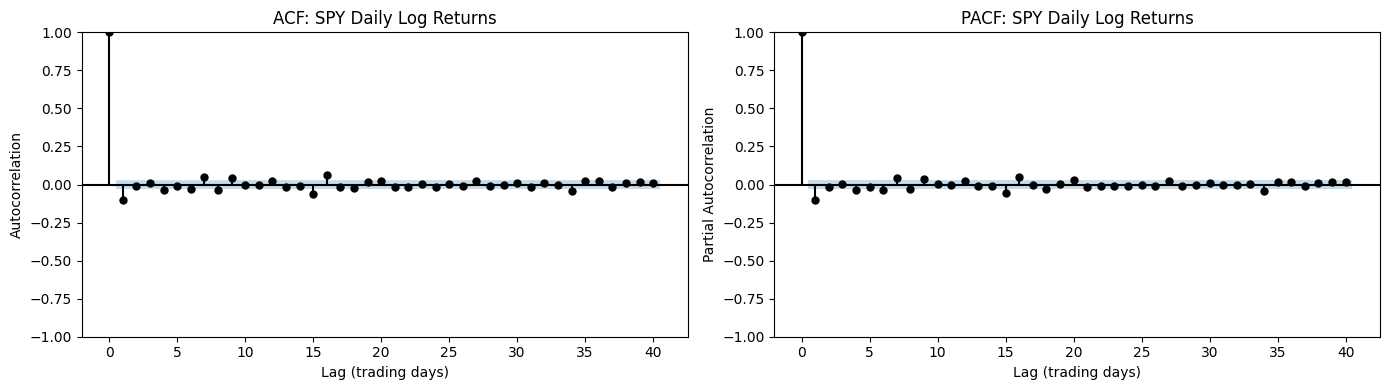

In [ ]:
# ============================================================
# ACF and PACF Plots for SPY Daily Log Returns
# ============================================================
# Autocorrelation Function (ACF): measures the correlation
# between a series and its lagged values. Strong, slowly
# decaying autocorrelation suggests an AR process.
#
# Partial Autocorrelation Function (PACF): measures the
# correlation between a series and a specific lag, after
# removing the effect of all shorter lags. A sharp cutoff
# in PACF suggests the AR order.
#
# For daily equity returns, we expect both plots to show
# very weak autocorrelation: nearly all lags within the
# 95% confidence bands (the shaded region). This would mean
# there is almost no exploitable serial dependence, and
# ARIMA has very little signal to work with.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot (40 lags = roughly 2 months of trading days)
plot_acf(
    df_prices['SPY_log_return'].dropna(),
    lags=40,
    ax=axes[0],
    color='black',
    vlines_kwargs={'colors': 'black'},
    alpha=0.05  # 95% confidence bands
)
axes[0].set_title('ACF: SPY Daily Log Returns', fontsize=12)
axes[0].set_xlabel('Lag (trading days)')
axes[0].set_ylabel('Autocorrelation')

# PACF plot
plot_pacf(
    df_prices['SPY_log_return'].dropna(),
    lags=40,
    ax=axes[1],
    color='black',
    vlines_kwargs={'colors': 'black'},
    alpha=0.05,
    method='ywm'  # Yule-Walker modified, stable for large samples
)
axes[1].set_title('PACF: SPY Daily Log Returns', fontsize=12)
axes[1].set_xlabel('Lag (trading days)')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

The ACF and PACF plots confirm what the academic literature has documented for decades: daily equity returns exhibit almost no serial dependence.

- Nearly every lag in both plots falls within the 95% confidence bands (the shaded blue region), meaning we cannot distinguish the autocorrelation from zero at any meaningful significance level
- The ACF shows a small negative spike at lag 1, which is common in equity returns and is often attributed to bid-ask bounce and microstructure effects rather than any tradable pattern
- The PACF tells the same story: no sharp cutoff at any lag, no decaying pattern, nothing that suggests an AR or MA process of any order

This is what "no signal" looks like in the autocorrelation domain. ARIMA models work by exploiting serial dependence: if today's return is correlated with yesterday's, the model can use that relationship to forecast tomorrow. These plots show that the correlation is effectively zero at every lag. The model has nothing to work with.

We will confirm this with `auto_arima`, which searches over possible model orders and selects the one that minimizes information criteria. If the best model it can find is trivial (low order, tiny coefficients), that is the model telling us the same thing these plots are showing visually.

In [ ]:
# ============================================================
# Auto-ARIMA Order Selection (Exploratory Only)
# ============================================================
# pmdarima's auto_arima searches over combinations of (p,d,q)
# and selects the model that minimizes AIC (Akaike Information
# Criterion). Lower AIC means a better balance between model
# fit and complexity.
#
# IMPORTANT: this is an exploratory step on the FULL sample.
# We are not using this model to trade. We are asking: what is
# the best ARIMA structure that the data supports? If the answer
# is a trivial model (e.g., (0,0,0) or (1,0,1) with tiny
# coefficients), that tells us something important about the
# forecastability of this series.
#
# We fix d=0 because the ADF test already confirmed that log
# returns are stationary, so no differencing is needed.
# ============================================================

print("Running auto_arima on SPY daily log returns (full sample)...")
print("This searches over candidate (p,d,q) orders to minimize AIC.\n")

auto_model = pm.auto_arima(
    df_prices['SPY_log_return'],
    d=0,                    # No differencing needed (series is stationary)
    start_p=0, max_p=5,    # Search AR orders 0 through 5
    start_q=0, max_q=5,    # Search MA orders 0 through 5
    seasonal=False,         # No seasonal component for daily returns
    stepwise=True,          # Stepwise search (faster than exhaustive grid)
    suppress_warnings=True,
    trace=False             # Set to True to see the full search log
)

print(f"Selected order: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.2f}\n")
print(auto_model.summary())

Running auto_arima on SPY daily log returns (full sample)...
This searches over candidate (p,d,q) orders to minimize AIC.

Selected order: ARIMA(0, 0, 1)
AIC: -27728.04

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4677
Model:               SARIMAX(0, 0, 1)   Log Likelihood               13867.020
Date:                Tue, 28 Jul 2026   AIC                         -27728.041
Time:                        14:08:14   BIC                         -27708.689
Sample:                             0   HQIC                        -27721.235
                               - 4677                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0004      0.000      2.

### How to read an ARIMA model summary

The output above is a standard `statsmodels` SARIMAX results table. If you have not seen one before, here is what to look for and what each section means.

**Model selection:** `auto_arima` chose ARIMA(0, 0, 1). The three numbers represent:

- **p = 0 (AR order):** no autoregressive terms. The model is not using any lagged return values to predict the next return.
- **d = 0 (differencing):** no differencing applied. We fixed this because the ADF test confirmed stationarity.
- **q = 1 (MA order):** one moving average term. The model uses yesterday's forecast error (the difference between what it predicted and what actually happened) to adjust today's forecast.

In plain language, the best model `auto_arima` could find is: "tomorrow's return equals a constant plus a small adjustment based on how wrong I was yesterday." That is not much of a model.

**Coefficient table:** three rows, each representing a model parameter:

- `intercept` (0.0004): the model's estimate of the average daily return, roughly 0.04% per day. The p-value of 0.023 means this is statistically significant, but economically it is tiny and almost impossible to trade on.
- `ma.L1` (-0.1059): the moving average coefficient. A value of -0.106 means the model adjusts its forecast by about 10% of yesterday's error, in the opposite direction. If the model over-predicted yesterday, it nudges down today. This is the only "signal" the model found, and it is weak.
- `sigma2` (0.0002): the estimated variance of the residuals. This is not a trading parameter; it measures the noise left over after the model has done its best.

**What to look for in the coefficient table:**

- **Magnitude of coefficients:** small coefficients mean the model is making tiny adjustments. An `ma.L1` of -0.106 is a 10% correction, applied to an error that is itself close to zero most days.
- **Statistical significance (P>|z|):** all three are significant (p < 0.05). But statistical significance and economic significance are different things. A coefficient can be reliably different from zero and still too small to trade on.
- **Confidence intervals ([0.025, 0.975]):** these give you the range of plausible values for each coefficient. The `ma.L1` interval is [-0.120, -0.092], so the coefficient is consistently negative but consistently small.

**Diagnostic statistics (bottom section):**

- `Ljung-Box (Q) = 0.00, Prob(Q) = 0.99`: tests whether the residuals still contain autocorrelation. A high p-value (0.99) means the model has captured whatever serial dependence existed. Good for the model, but only because there was almost nothing to capture.
- `Jarque-Bera (JB) = 33,780, Prob(JB) = 0.00`: tests whether the residuals are normally distributed. The enormous test statistic and zero p-value tell us they are not. Financial returns have fat tails (kurtosis of 16.14 vs. 3.0 for a normal distribution) and slight negative skew (-0.45). ARIMA assumes normal errors; this violation does not break the model but means confidence intervals and p-values are approximate.
- `Heteroskedasticity (H) = 0.69, Prob(H) = 0.00`: tests whether the variance of residuals is constant over time. It is not. Financial returns exhibit volatility clustering (calm periods followed by turbulent periods). ARIMA cannot capture this; it is a linear model applied to a process with nonlinear variance dynamics.

**The bottom line:** `auto_arima` searched through dozens of candidate models and the best it could find was a single MA(1) term with a coefficient of -0.106. The model is telling us, in the most precise way it can, that there is almost nothing to forecast in daily SPY returns. We will now test whether even this minimal signal translates into a usable trading edge.

## Section 2: Walk-Forward Evaluation on SPY Returns

### The only valid way to evaluate a forecasting model

Most online ARIMA tutorials split the data once (say, 80% train, 20% test), fit the model on the training set, call `.forecast(steps=N)` for the entire test period, and declare success if the forecast line looks reasonable on a chart. This is wrong for two reasons:

- **Multi-step forecasting compounds errors.** Each forecast step uses the previous forecast as input, so errors accumulate rapidly. By day 50, the forecast has drifted away from reality and is essentially extrapolating the unconditional mean.
- **No real trader refits once and walks away.** In practice, you would update your model every day with the latest data. A single train/test split does not reflect how the model would actually be used.

Walk-forward one-step-ahead forecasting fixes both problems:

1. Start with a rolling window of `TRAIN_WINDOW` days (504, roughly 2 years)
2. Fit ARIMA on the window
3. Forecast only the next day's return (one step ahead)
4. Record the forecast and the actual return
5. Roll the window forward by one day
6. Repeat until the end of the series

This produces one out-of-sample forecast per day, each made using only data that was available at the time. No lookahead, no compounding forecast errors, no methodological shortcuts.

### A note on runtime

The loop below refits an ARIMA(0, 0, 1) model 4,173 times, once for each trading day in our evaluation period. This took about 7 minutes on the Colab runtime we were assigned, and yours may differ depending on the machine you get. You do not need to execute this cell yourself to follow the notebook. We ran it and the results are shown in the cells that follow. If you want to verify the results or experiment with different parameters, set aside the time and let it run.

In [ ]:
# ============================================================
# Walk-Forward One-Step-Ahead ARIMA Forecasting
# ============================================================
# This is the core experiment. For each trading day in the
# evaluation period, we:
#   1. Take the most recent TRAIN_WINDOW days of log returns
#   2. Fit ARIMA(0, 0, 1) on that window
#   3. Forecast the next day's return
#   4. Record the forecast alongside the actual return
#   5. Roll forward one day and repeat
#
# We use the fixed order (0,0,1) from auto_arima rather than
# re-running auto_arima at each step. Re-running would be
# more thorough but would take hours instead of minutes, and
# auto_arima consistently selects (0,0,1) on daily returns
# regardless of the window. Fixing the order is both faster
# and more transparent.
#
# Runtime: roughly 7 minutes in Google Colab. This will vary
# with the machine you are assigned and the pandas and
# statsmodels versions in the runtime.
# ============================================================

returns = df_prices['SPY_log_return'].values
dates = df_prices.index

# Storage for results
forecasts = []
actuals = []
forecast_dates = []
convergence_failures = 0

# The evaluation period starts after the first full training window
n_forecasts = len(returns) - TRAIN_WINDOW
print(f"Walk-forward loop: {n_forecasts:,} forecasts to generate")
print(f"Training window: {TRAIN_WINDOW} days")
print(f"Model order: ARIMA(0, 0, 1)\n")

start_time = time.time()

for i in range(n_forecasts):
    # Extract the rolling training window
    train = returns[i : i + TRAIN_WINDOW]

    try:
        # Fit ARIMA(0, 0, 1) on the training window
        model = SARIMAX(
            train,
            order=(0, 0, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=100)

        # Forecast one step ahead
        forecast = fitted.forecast(steps=1)[0]

    except Exception:
        # If the model fails to converge, record NaN.
        # This happens occasionally with unusual data windows.
        forecast = np.nan
        convergence_failures += 1

    # The actual return is the next day after the training window
    actual = returns[i + TRAIN_WINDOW]

    forecasts.append(forecast)
    actuals.append(actual)
    forecast_dates.append(dates[i + TRAIN_WINDOW])

    # Progress reporting every 1000 steps
    if (i + 1) % 1000 == 0 or (i + 1) == n_forecasts:
        elapsed = time.time() - start_time
        pct = (i + 1) / n_forecasts * 100
        print(f"  Step {i+1:,} / {n_forecasts:,} ({pct:.0f}%) "
              f"- Elapsed: {elapsed:.0f}s")

elapsed_total = time.time() - start_time
print(f"\nWalk-forward complete.")
print(f"  Forecasts generated: {len(forecasts):,}")
print(f"  Convergence failures: {convergence_failures}")
print(f"  Total runtime: {elapsed_total/60:.1f} minutes")

# Store results in a DataFrame for analysis
df_wf = pd.DataFrame({
    'forecast': forecasts,
    'actual': actuals
}, index=forecast_dates)

# Drop any rows where the model failed to converge
df_wf = df_wf.dropna()
print(f"  Usable forecasts: {len(df_wf):,}")

Walk-forward loop: 4,173 forecasts to generate
Training window: 504 days
Model order: ARIMA(0, 0, 1)

  Step 1,000 / 4,173 (24%) - Elapsed: 123s
  Step 2,000 / 4,173 (48%) - Elapsed: 199s
  Step 3,000 / 4,173 (72%) - Elapsed: 301s
  Step 4,000 / 4,173 (96%) - Elapsed: 402s
  Step 4,173 / 4,173 (100%) - Elapsed: 421s

Walk-forward complete.
  Forecasts generated: 4,173
  Convergence failures: 0
  Total runtime: 7.0 minutes
  Usable forecasts: 4,173


The walk-forward loop completed in about 7 minutes with no convergence failures across 4,173 forecasts. Each forecast was generated using only the preceding 504 days of data, with no access to future information.

Now we convert these forecasts into a trading signal and see whether ARIMA's predictions translate into a usable edge.

## Section 3: ARIMA as a Trading Signal

The signal logic is as simple and generous as possible:

- If ARIMA forecasts a **positive** return for tomorrow, go long SPY
- If ARIMA forecasts a **negative or zero** return, hold BIL (risk-free)
- No transaction costs, no slippage, perfect execution at the close

This is the most favorable test we can give the model. In practice, transaction costs and slippage would eat into any marginal edge (not to mention we need to trade at the next day's open!). If the model cannot beat buy-and-hold under these ideal conditions, it has no chance in the real world.

In [ ]:
# ============================================================
# Convert Forecasts to Trading Signal and Strategy Returns
# ============================================================
# Signal logic:
#   forecast > 0  →  long SPY (signal = 1)
#   forecast <= 0 →  hold BIL (signal = 0)
#
# Strategy return on each day:
#   signal * SPY_return + (1 - signal) * BIL_return
#
# This gives the model every advantage: no costs, no slippage,
# and we use the actual close-to-close return (no execution lag).
# Even with these generous assumptions, we expect the model to
# struggle because its forecasts are tiny and nearly random.
# ============================================================

# Align BIL returns with the forecast dates
df_eval = df_wf.copy()
df_eval['SPY_return'] = df_prices.loc[df_eval.index, 'SPY'].pct_change()
df_eval['BIL_return'] = df_prices.loc[df_eval.index, 'BIL'].pct_change()
df_eval = df_eval.dropna()

# Generate signal: 1 = long SPY, 0 = hold BIL
df_eval['signal'] = (df_eval['forecast'] > 0).astype(int)

# Strategy return: SPY when signal is 1, BIL when signal is 0
df_eval['strategy_return'] = (
    df_eval['signal'] * df_eval['SPY_return'] +
    (1 - df_eval['signal']) * df_eval['BIL_return']
)

# Buy-and-hold benchmark: 100% SPY every day
df_eval['buyhold_return'] = df_eval['SPY_return']

# Cumulative returns (growth of $1)
df_eval['strategy_cumulative'] = (1 + df_eval['strategy_return']).cumprod()
df_eval['buyhold_cumulative'] = (1 + df_eval['buyhold_return']).cumprod()

# Hit rate: how often did the forecast correctly predict direction?
df_eval['correct'] = (
    (df_eval['forecast'] > 0) & (df_eval['actual'] > 0) |
    (df_eval['forecast'] <= 0) & (df_eval['actual'] <= 0)
)
hit_rate = df_eval['correct'].mean()

# Signal distribution
n_long = df_eval['signal'].sum()
n_safe = len(df_eval) - n_long

print(f"Evaluation period: {df_eval.index[0].strftime('%Y-%m-%d')} to "
      f"{df_eval.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(df_eval):,}\n")
print(f"Signal distribution:")
print(f"  Long SPY: {n_long:,} days ({n_long/len(df_eval)*100:.1f}%)")
print(f"  Hold BIL: {n_safe:,} days ({n_safe/len(df_eval)*100:.1f}%)\n")
print(f"Directional accuracy (hit rate): {hit_rate:.4f} ({hit_rate*100:.1f}%)")

Evaluation period: 2009-06-02 to 2025-12-30
Trading days: 4,172

Signal distribution:
  Long SPY: 1,914 days (45.9%)
  Hold BIL: 2,258 days (54.1%)

Directional accuracy (hit rate): 0.4835 (48.3%)


Two numbers tell the whole story before we even look at returns:

- **Hit rate of 48.3%:** worse than a coin flip. The model is not just failing to predict direction; it is getting it wrong more often than random guessing would.
- **54.1% of days in BIL:** the model forecasts negative returns more often than positive. Since the equity market has a positive drift (it goes up more days than it goes down), a model that leans bearish is fighting the base rate. It will miss the up days that drive long-term compounding.

This is a direct consequence of what we saw in the ACF/PACF plots. The model's only tool is a small MA(1) coefficient of -0.106, which slightly reverses yesterday's error. On days after a strong positive return, the adjustment nudges the forecast toward zero or slightly negative, pulling the model out of the market on days that are often followed by more gains. The model is not identifying real patterns; it is reacting to noise with a tiny, mean-reverting correction that happens to lean the wrong way.

The performance metrics will confirm what these numbers already imply.

In [ ]:
# ============================================================
# Inline Performance Evaluation
# ============================================================
# We calculate the standard metrics from scratch rather than
# importing an external library. This keeps the notebook
# self-contained and reinforces the Chapter 7 material.
#
# Metrics calculated:
#   - Total cumulative return (growth of $1)
#   - Annualized return (CAGR)
#   - Annualized volatility
#   - Sharpe ratio (with risk-free rate = 0)
#   - Maximum drawdown
#   - Hit rate (directional accuracy, strategy only)
# ============================================================

def calc_metrics(returns, label, hit_rate=None):
    """
    Calculate standard performance metrics from a daily return series.
    Returns a dictionary suitable for building a comparison table.
    """
    # Total cumulative return
    cum_return = (1 + returns).cumprod().iloc[-1] - 1

    # Annualized return (CAGR)
    n_years = len(returns) / TRADING_DAYS_PER_YEAR
    cagr = (1 + cum_return) ** (1 / n_years) - 1

    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

    # Sharpe ratio (excess return over risk-free, annualized)
    sharpe = (cagr - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0.0

    # Maximum drawdown: largest peak-to-trough decline
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()

    metrics = {
        'Total Return': f"{cum_return:.2%}",
        'CAGR': f"{cagr:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.2%}",
    }
    if hit_rate is not None:
        metrics['Hit Rate'] = f"{hit_rate:.2%}"

    return metrics

# Calculate metrics for both strategy and benchmark
strategy_metrics = calc_metrics(
    df_eval['strategy_return'], 'ARIMA Strategy', hit_rate=hit_rate
)
buyhold_metrics = calc_metrics(
    df_eval['buyhold_return'], 'SPY Buy-and-Hold'
)

# Build comparison table
df_comparison = pd.DataFrame({
    'ARIMA Strategy': strategy_metrics,
    'SPY Buy-and-Hold': buyhold_metrics
})

print(df_comparison.to_string())

                ARIMA Strategy SPY Buy-and-Hold
Total Return           108.45%          881.56%
CAGR                     4.54%           14.79%
Ann. Volatility         12.53%           17.20%
Sharpe Ratio              0.36             0.86
Max Drawdown           -31.00%          -33.72%
Hit Rate                48.35%              NaN


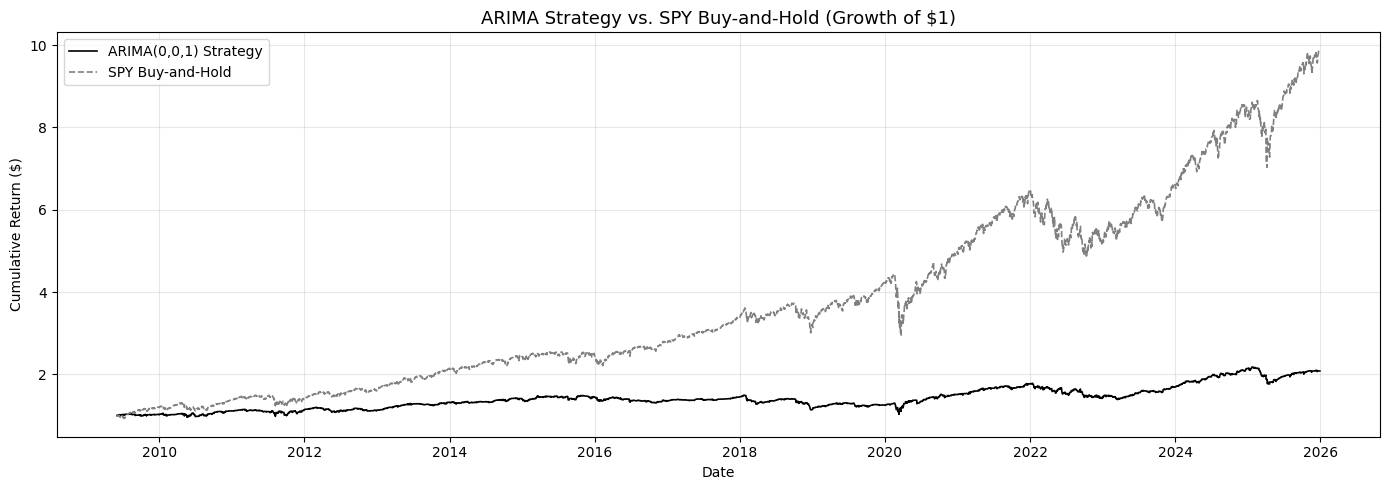

In [ ]:
# ============================================================
# Equity Curve: ARIMA Strategy vs. SPY Buy-and-Hold
# ============================================================
# This is the chart that converts the performance table into
# a visual. The gap between the two lines is the cost of
# trying to time the market with a model that has no edge.
#
# Grayscale-friendly: solid line for strategy, dashed for
# benchmark, distinct enough for print reproduction.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_eval.index, df_eval['strategy_cumulative'],
    color='black', linewidth=1.2, linestyle='-',
    label='ARIMA(0,0,1) Strategy'
)
ax.plot(
    df_eval.index, df_eval['buyhold_cumulative'],
    color='grey', linewidth=1.2, linestyle='--',
    label='SPY Buy-and-Hold'
)

ax.set_title('ARIMA Strategy vs. SPY Buy-and-Hold (Growth of $1)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Why ARIMA Fails on Daily Equity Returns

The equity curve makes the failure undeniable. A dollar invested in the ARIMA strategy in 2009 grew to about `$`2.08 by the end of 2025. The same dollar in SPY buy-and-hold grew to nearly $9.82. The model did not just fail to add value; it actively destroyed it by pulling you out of the market on days that turned out to be positive.

The diagnosis is structural, not technical. There is no parameter tuning, window length, or model order that fixes this:

1. **Daily equity returns have near-zero autocorrelation.** The ACF/PACF showed this. The model's only tool (a small MA(1) correction) has almost nothing to work with.
2. **The model's forecasts cluster around zero.** When the expected return is approximately zero every day, the signal flips between long and safe on noise rather than information. The 54/46 split toward BIL tells you the model leans slightly bearish in a market with a structural upward drift.
3. **Missing strong up days is catastrophic for long-term compounding.** The best days in the market tend to cluster around the worst days. A model that goes to cash during volatile periods (when its error corrections are largest) will miss the recoveries that drive buy-and-hold returns.
4. **ARIMA captures linear dependence only.** Financial returns exhibit nonlinear dependence through volatility clustering (calm periods followed by turbulent periods). ARIMA cannot see this structure. It is the wrong tool for the job.

This is not a failure of our implementation. We used the correct methodology (walk-forward, one-step-ahead, rolling window), the correct data transformation (log returns, not prices), and the model order that `auto_arima` identified as optimal. The failure is in the premise: **trying to predict the daily return of an equity index using price history alone is a fool's errand.** The signal simply is not there. No amount of methodological rigor can extract a pattern that does not exist.

If you encounter a GitHub repository or Medium article claiming otherwise, the error is in their evaluation, not in your skepticism. The most common culprits: fitting on the full sample and "predicting" in-sample, using a single train/test split instead of walk-forward, evaluating on price RMSE instead of trading profitability, or introducing lookahead bias through data preprocessing. We will see several of these mistakes again in Notebook 3 when we examine Prophet.

The question is not whether ARIMA is a useful model. It is. The question is whether the data you are applying it to has the statistical properties it needs. Daily equity returns do not. In the next section, we test a series that does.

## Section 5: ARIMA on VIX (Where the Model Actually Works)

Everything that made SPY returns a poor candidate for ARIMA makes the VIX a good one:

- **Mean-reverting by construction.** The VIX measures implied volatility, which spikes during market stress and reverts to a long-run average during calm periods. This creates the persistent, decaying autocorrelation structure that ARIMA is designed to capture.
- **Strong serial dependence.** A high VIX today tells you something meaningful about tomorrow's VIX. A positive SPY return today tells you almost nothing about tomorrow's SPY return.
- **Regime persistence.** Volatility regimes last for weeks or months, not hours. ARIMA can model this slow mean-reversion process.

We apply the same rigorous framework from Sections 2 through 4: stationarity testing, ACF/PACF analysis, and walk-forward evaluation. The goal is not to build a VIX trading strategy (VIX is not directly tradable as an equity position), but to demonstrate the contrast. When ARIMA's assumptions are met, the model produces meaningful forecasts. When they are not, you get the equity curve from Section 4.

We start by examining the autocorrelation structure of VIX, which should look very different from what we saw with SPY returns.

ADF Test: VIX Levels
  Test Statistic: -5.5871
  p-value:        0.000001
  Lags Used:      10
  Observations:   4666
  Critical Values:
    1%: -3.4318
    5%: -2.8622
    10%: -2.5671
  Conclusion: STATIONARY (p < 0.05, reject unit root)

ADF Test: VIX Daily Changes
  Test Statistic: -23.6676
  p-value:        0.000000
  Lags Used:      9
  Observations:   4666
  Critical Values:
    1%: -3.4318
    5%: -2.8622
    10%: -2.5671
  Conclusion: STATIONARY (p < 0.05, reject unit root)



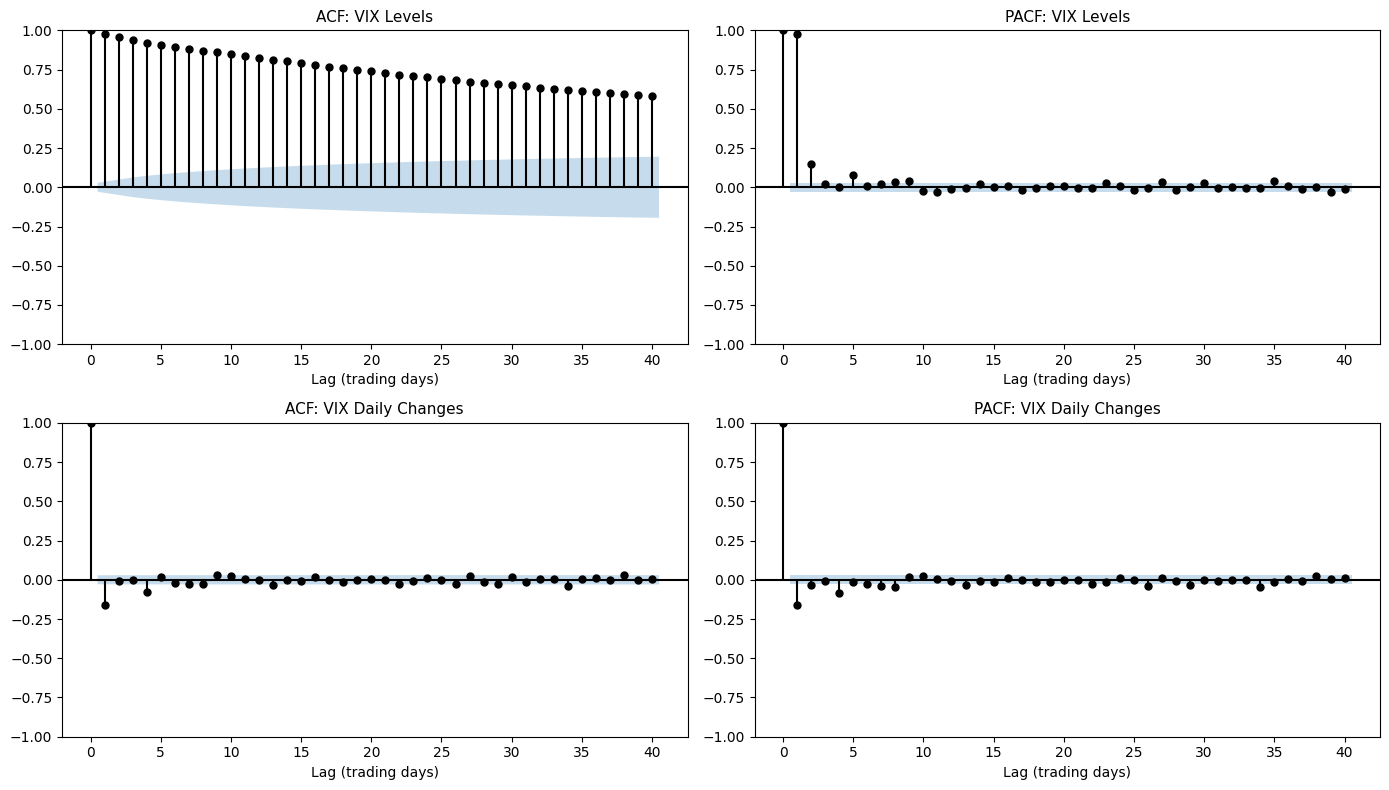

In [ ]:
# ============================================================
# VIX Stationarity Testing and ACF/PACF
# ============================================================
# We test two versions of VIX:
#   1. VIX levels: the raw index value (e.g., 14.33)
#   2. VIX daily changes: the first difference (today minus yesterday)
#
# VIX levels may or may not pass the ADF test depending on the
# sample period. The index trends upward during crises and
# downward during calm markets, which can look non-stationary
# over certain windows. VIX changes should be clearly stationary.
#
# The key comparison is the ACF/PACF structure vs. what we saw
# for SPY. If VIX shows strong, slowly decaying autocorrelation,
# that is exactly the pattern ARIMA is built to exploit.
# ============================================================

# Calculate VIX daily changes
df_prices['VIX_change'] = df_prices['VIX'].diff()

# --- ADF Tests ---
print("=" * 55)
run_adf_test(df_prices['VIX'], 'VIX Levels')
print("=" * 55)
run_adf_test(df_prices['VIX_change'].dropna(), 'VIX Daily Changes')

# --- ACF/PACF for VIX Levels ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: VIX levels
plot_acf(
    df_prices['VIX'].dropna(), lags=40, ax=axes[0, 0],
    color='black', vlines_kwargs={'colors': 'black'}, alpha=0.05
)
axes[0, 0].set_title('ACF: VIX Levels', fontsize=11)
axes[0, 0].set_xlabel('Lag (trading days)')

plot_pacf(
    df_prices['VIX'].dropna(), lags=40, ax=axes[0, 1],
    color='black', vlines_kwargs={'colors': 'black'},
    alpha=0.05, method='ywm'
)
axes[0, 1].set_title('PACF: VIX Levels', fontsize=11)
axes[0, 1].set_xlabel('Lag (trading days)')

# Bottom row: VIX daily changes
plot_acf(
    df_prices['VIX_change'].dropna(), lags=40, ax=axes[1, 0],
    color='black', vlines_kwargs={'colors': 'black'}, alpha=0.05
)
axes[1, 0].set_title('ACF: VIX Daily Changes', fontsize=11)
axes[1, 0].set_xlabel('Lag (trading days)')

plot_pacf(
    df_prices['VIX_change'].dropna(), lags=40, ax=axes[1, 1],
    color='black', vlines_kwargs={'colors': 'black'},
    alpha=0.05, method='ywm'
)
axes[1, 1].set_title('PACF: VIX Daily Changes', fontsize=11)
axes[1, 1].set_xlabel('Lag (trading days)')

plt.tight_layout()
plt.show()

The contrast with SPY could not be more dramatic.

**ADF tests:**

- VIX levels are stationary (p < 0.001), which is the statistical confirmation of what practitioners already know: VIX mean-reverts. It spikes, then comes back down. Unlike SPY prices, which trend upward indefinitely, VIX has a gravitational pull toward a long-run average.
- VIX daily changes are also stationary, with an even stronger test statistic (-23.67 vs. -5.59).

**ACF/PACF (top row, VIX levels):**

- The ACF shows strong, slowly decaying autocorrelation that remains above 0.6 even at lag 40. Compare this to SPY returns where every single lag was inside the confidence bands. This is exactly the pattern ARIMA is designed to model: persistent serial dependence that decays gradually over time.
- The PACF shows a sharp spike at lag 1 and smaller spikes at lags 2 and 5, suggesting an AR process with a dominant first-order term. This is what mean-reversion looks like in the PACF: today's VIX is strongly predicted by yesterday's VIX, with diminishing contributions from earlier lags.

**ACF/PACF (bottom row, VIX daily changes):**

- The pattern is weaker but still more structured than SPY returns. There is a meaningful negative spike at lag 1 in both ACF and PACF, suggesting an MA(1) or AR(1) component in the differenced series.

For the walk-forward evaluation, we will model VIX levels directly since they passed the ADF test and show the strongest autocorrelation structure. The model should be able to capture the mean-reverting dynamics and produce forecasts that track the actual VIX meaningfully better than what we saw with SPY returns.

In [ ]:
# ============================================================
# Auto-ARIMA on VIX Levels (Exploratory)
# ============================================================
# Same exploratory step as Section 2: run auto_arima on the
# full sample to identify the best (p,d,q) order, then use
# that fixed order in the walk-forward loop.
#
# We expect a higher-order model than the (0,0,1) that SPY
# returned, because VIX has genuine autocorrelation structure
# for the model to capture.
# ============================================================

print("Running auto_arima on VIX levels (full sample)...\n")

auto_model_vix = pm.auto_arima(
    df_prices['VIX'],
    d=0,                    # ADF confirmed stationarity
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=False
)

print(f"Selected order: ARIMA{auto_model_vix.order}")
print(f"AIC: {auto_model_vix.aic():.2f}\n")
print(auto_model_vix.summary())

Running auto_arima on VIX levels (full sample)...

Selected order: ARIMA(1, 0, 4)
AIC: 19618.82

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4677
Model:               SARIMAX(1, 0, 4)   Log Likelihood               -9802.411
Date:                Tue, 28 Jul 2026   AIC                          19618.823
Time:                        14:16:55   BIC                          19663.976
Sample:                             0   HQIC                         19634.702
                               - 4677                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2758      0.049      5.604      0.000       0.179       0.372
ar.L1          0.9861      0.001  

The model summary confirms what the ACF/PACF plots predicted. Two things jump out:

- **ARIMA(1, 0, 4) vs. ARIMA(0, 0, 1) for SPY.** The VIX data supports a substantially more complex model: one AR term and four MA terms, compared to a single MA term for SPY returns. The data has enough structure for the model to justify the additional complexity.
- **The AR(1) coefficient is 0.986.** This is the fingerprint of a mean-reverting process. A coefficient just below 1.0 means today's VIX is almost entirely explained by yesterday's VIX, with a slow pull toward the intercept (the long-run mean). For comparison, SPY returns had no AR term at all.

The Jarque-Bera statistic (122,368) and kurtosis (27.62) tell us VIX has even fatter tails than SPY returns, driven by the occasional extreme spike (March 2020, August 2024). The model will struggle with those spikes, but it should track the mean-reverting behavior well during normal conditions.

We now run the same walk-forward framework on VIX levels, using the fixed order (1, 0, 4).

In [ ]:
# ============================================================
# Walk-Forward One-Step-Ahead ARIMA on VIX Levels
# ============================================================
# Identical methodology to the SPY walk-forward in Section 2.
# The only differences:
#   - Input series: VIX levels instead of SPY log returns
#   - Model order: (1, 0, 4) instead of (0, 0, 1)
#
# We are not building a trading strategy here because VIX
# is not directly tradable as an equity position. The purpose
# is to compare forecast quality: does ARIMA produce more
# meaningful predictions when the data meets its assumptions?
#
# Runtime: roughly 21 minutes, about three times the SPY loop,
# because the higher model order means five parameters to
# estimate per fit instead of two.
# ============================================================

vix = df_prices['VIX'].values

# Storage for results
vix_forecasts = []
vix_actuals = []
vix_forecast_dates = []
vix_failures = 0

n_vix_forecasts = len(vix) - TRAIN_WINDOW
print(f"Walk-forward loop: {n_vix_forecasts:,} forecasts to generate")
print(f"Training window: {TRAIN_WINDOW} days")
print(f"Model order: ARIMA(1, 0, 4)\n")

start_time = time.time()

for i in range(n_vix_forecasts):
    train = vix[i : i + TRAIN_WINDOW]

    try:
        model = SARIMAX(
            train,
            order=(1, 0, 4),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=100)
        forecast = fitted.forecast(steps=1)[0]

    except Exception:
        forecast = np.nan
        vix_failures += 1

    actual = vix[i + TRAIN_WINDOW]

    vix_forecasts.append(forecast)
    vix_actuals.append(actual)
    vix_forecast_dates.append(dates[i + TRAIN_WINDOW])

    if (i + 1) % 1000 == 0 or (i + 1) == n_vix_forecasts:
        elapsed = time.time() - start_time
        pct = (i + 1) / n_vix_forecasts * 100
        print(f"  Step {i+1:,} / {n_vix_forecasts:,} ({pct:.0f}%) "
              f"- Elapsed: {elapsed:.0f}s")

elapsed_total = time.time() - start_time
print(f"\nWalk-forward complete.")
print(f"  Forecasts generated: {len(vix_forecasts):,}")
print(f"  Convergence failures: {vix_failures}")
print(f"  Total runtime: {elapsed_total/60:.1f} minutes")

# Store results
df_vix_wf = pd.DataFrame({
    'forecast': vix_forecasts,
    'actual': vix_actuals
}, index=vix_forecast_dates)

df_vix_wf = df_vix_wf.dropna()
print(f"  Usable forecasts: {len(df_vix_wf):,}")

Walk-forward loop: 4,173 forecasts to generate
Training window: 504 days
Model order: ARIMA(1, 0, 4)

  Step 1,000 / 4,173 (24%) - Elapsed: 350s
  Step 2,000 / 4,173 (48%) - Elapsed: 635s
  Step 3,000 / 4,173 (72%) - Elapsed: 900s
  Step 4,000 / 4,173 (96%) - Elapsed: 1200s
  Step 4,173 / 4,173 (100%) - Elapsed: 1247s

Walk-forward complete.
  Forecasts generated: 4,173
  Convergence failures: 0
  Total runtime: 20.8 minutes
  Usable forecasts: 4,173


The VIX walk-forward took about 21 minutes with zero convergence failures, roughly three times longer than the SPY loop due to the higher model order (five parameters to estimate vs. two).

Since VIX is not directly tradable as an equity position, we cannot evaluate the model with an equity curve the way we did for SPY. Instead, we assess forecast quality directly:

- **Directional accuracy:** did the model correctly predict whether VIX would go up or down the next day? This is the most direct comparison with the SPY result (48.3%).
- **RMSE and MAE:** how far off were the point forecasts in VIX points?
- **Correlation:** how closely do the forecasted VIX levels track the actual values?

If the model is capturing VIX's mean-reverting dynamics, we should see meaningfully better directional accuracy than the near-random result we got for SPY returns.

In [ ]:
# ============================================================
# VIX Forecast Evaluation
# ============================================================
# Since VIX is not directly tradable as an equity position,
# we evaluate forecast quality rather than trading profitability.
#
# Metrics:
#   - Directional accuracy: did the model correctly predict
#     whether VIX would go up or down the next day?
#   - RMSE and MAE: how far off were the point forecasts?
#   - Correlation: forecast vs. actual
#
# We compare directional accuracy against the SPY result
# (48.3%) to quantify the difference between modeling data
# that meets ARIMA's assumptions vs. data that does not.
# ============================================================

# Calculate actual VIX daily changes for directional comparison
df_vix_wf['actual_change'] = df_vix_wf['actual'].diff()
df_vix_wf['forecast_change'] = df_vix_wf['forecast'] - df_vix_wf['actual'].shift(1)
df_vix_wf = df_vix_wf.dropna()

# Directional accuracy: did forecast predict the right direction of change?
df_vix_wf['correct_direction'] = (
    (df_vix_wf['forecast_change'] > 0) & (df_vix_wf['actual_change'] > 0) |
    (df_vix_wf['forecast_change'] <= 0) & (df_vix_wf['actual_change'] <= 0)
)
vix_hit_rate = df_vix_wf['correct_direction'].mean()

# Forecast error metrics
errors = df_vix_wf['forecast'] - df_vix_wf['actual']
rmse = np.sqrt((errors ** 2).mean())
mae = errors.abs().mean()

# Correlation between forecast and actual levels
correlation = df_vix_wf['forecast'].corr(df_vix_wf['actual'])

print("VIX Forecast Quality Metrics")
print("=" * 45)
print(f"  Directional accuracy:  {vix_hit_rate:.4f} ({vix_hit_rate*100:.1f}%)")
print(f"  SPY directional accuracy (Section 3): 48.3%")
print(f"  RMSE:                  {rmse:.4f}")
print(f"  MAE:                   {mae:.4f}")
print(f"  Forecast-Actual corr:  {correlation:.4f}")
print(f"  Evaluation days:       {len(df_vix_wf):,}")

VIX Forecast Quality Metrics
  Directional accuracy:  0.5151 (51.5%)
  SPY directional accuracy (Section 3): 48.3%
  RMSE:                  1.8736
  MAE:                   1.1059
  Forecast-Actual corr:  0.9628
  Evaluation days:       4,172


The results require careful reading because the two metrics point in different directions:

- **Directional accuracy (51.5% vs. 48.3% for SPY):** better than SPY, but only marginally above a coin flip. Predicting daily direction is hard even for mean-reverting data, because VIX can drift in one direction for several days before reverting. The model gets the overall level right but still struggles with the exact timing of daily reversals.
- **Forecast-actual correlation (0.9628):** this is the number that matters. The model's predicted VIX level tracks the actual VIX level with near-perfect correlation. It knows roughly where VIX should be; it just cannot reliably tell you whether tomorrow will be slightly up or slightly down from today.
- **MAE of 1.1 VIX points:** the average forecast misses by about 1 point. When VIX is at 20, that is a 5% error. When VIX is at 40 during a crisis, that is 2.75%. These are useful estimates, not precise predictions, but they are far more meaningful than anything the SPY model produced.

This distinction between level accuracy and directional accuracy is important. ARIMA captures the slow mean-reversion in VIX (where the index is heading over the next several days) but not the daily noise. That is exactly the kind of information that feeds a strategy like the VIXY tail hedge from our case study: you do not need to know whether VIX will be up or down tomorrow, you need to know whether it is elevated relative to its long-run average, and ARIMA can answer that question.

The scatter plot below makes the contrast with SPY visual.

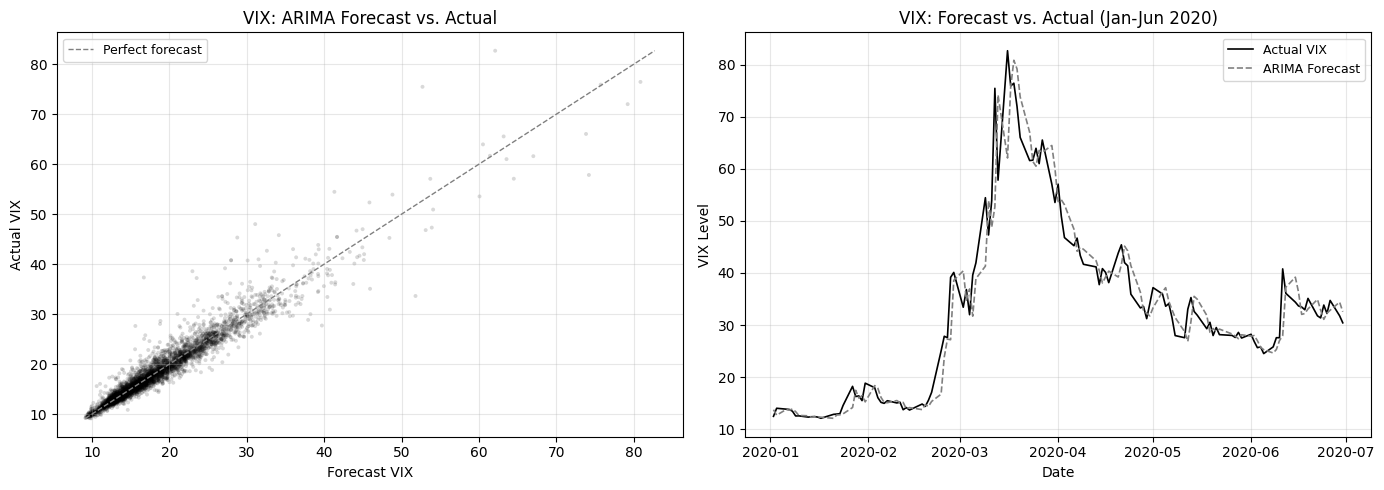

In [ ]:
# ============================================================
# VIX Forecast vs. Actual: Scatter and Time-Series Plots
# ============================================================
# Two panels:
#   Left: scatter plot of forecast vs. actual VIX levels.
#         A tight cluster along the 45-degree line means the
#         model is tracking the level well.
#   Right: 6-month time-series overlay showing forecast vs.
#          actual during a representative period that includes
#          both a spike and a reversion.
#
# Grayscale-friendly throughout.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: scatter plot ---
axes[0].scatter(
    df_vix_wf['forecast'], df_vix_wf['actual'],
    alpha=0.15, s=8, color='black', edgecolors='none'
)

# 45-degree reference line
scatter_min = min(df_vix_wf['forecast'].min(), df_vix_wf['actual'].min())
scatter_max = max(df_vix_wf['forecast'].max(), df_vix_wf['actual'].max())
axes[0].plot(
    [scatter_min, scatter_max], [scatter_min, scatter_max],
    color='grey', linestyle='--', linewidth=1, label='Perfect forecast'
)

axes[0].set_title('VIX: ARIMA Forecast vs. Actual', fontsize=12)
axes[0].set_xlabel('Forecast VIX')
axes[0].set_ylabel('Actual VIX')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Right panel: 6-month time-series overlay ---
# Use a period that includes the March 2020 spike and reversion
# to show how the model handles extreme moves
overlay_start = '2020-01-01'
overlay_end = '2020-06-30'
mask = (df_vix_wf.index >= overlay_start) & (df_vix_wf.index <= overlay_end)
df_overlay = df_vix_wf.loc[mask]

axes[1].plot(
    df_overlay.index, df_overlay['actual'],
    color='black', linewidth=1.2, linestyle='-', label='Actual VIX'
)
axes[1].plot(
    df_overlay.index, df_overlay['forecast'],
    color='grey', linewidth=1.2, linestyle='--', label='ARIMA Forecast'
)

axes[1].set_title('VIX: Forecast vs. Actual (Jan-Jun 2020)', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('VIX Level')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The two panels illustrate why the 0.96 correlation and the 51.5% directional accuracy are not contradictory.

- **Left panel (scatter):** the points cluster tightly along the 45-degree line, especially in the 10-30 range where VIX spends most of its time. The dispersion increases at higher levels (above 40), where the model lags behind extreme spikes. This is expected: sudden VIX spikes are driven by exogenous shocks (pandemic announcements, geopolitical events) that no time-series model can anticipate.
- **Right panel (Jan-Jun 2020):** the forecast tracks the actual VIX closely through the entire COVID crisis, lagging by roughly one day. When VIX spiked from 14 to 82 in March, the model could not predict the spike in advance, but it caught up within a day and tracked the subsequent decline accurately.

### Why does the forecast lag by one day?

Look closely at the right panel. The dashed forecast line tracks the actual almost perfectly, but offset by roughly a day. This is not a bug. It is a mechanical consequence of how the model works.

The AR(1) coefficient is 0.986. That means the forecast for tomorrow is approximately: 0.986 × today's VIX + 0.014 × long-run mean. Roughly 98.6% of tomorrow's forecast is just today's value, nudged slightly toward the mean. So when VIX jumps from 17 to 30 in a single day, the model's forecast for that day was made yesterday using yesterday's VIX of 17. It predicted something like 17.2. The next day it catches up because now it has 30 as its input and predicts something like 29.8. During rapid moves in either direction, the forecast is always one step behind because it can only use information available at the time of prediction. During stable periods, the lag is invisible because tomorrow really is close to today.

This leads to an important realization about what the model is actually doing. It is not "forecasting" in the way most people imagine. It is doing sophisticated smoothing: "tomorrow will be very close to today, with a small pull toward the long-run average." The 0.96 correlation looks impressive, but much of it comes from the persistence of VIX itself rather than genuine predictive power. VIX tomorrow really is close to VIX today most of the time. The model gets credit for a relationship that is largely mechanical.

This also explains the gap between the 0.96 correlation and the 51.5% directional accuracy. The model tracks the level well because levels persist. But predicting daily direction (will VIX be up or down tomorrow?) requires anticipating change, not echoing the present. The model is essentially predicting yesterday's move as tomorrow's move, which works during sustained trends and fails at every turning point.

### What this means in practice

- **For regime identification (is VIX elevated or not?):** the one-day lag is irrelevant. Regimes persist for weeks or months, so being one day late does not matter. This is exactly the kind of information that feeds a strategy like the VIXY tail hedge: the signal depends on knowing whether VIX is elevated relative to its average, not on predicting tomorrow's exact level.
- **For daily direction prediction:** the lag is fatal. The model cannot anticipate turning points, which is why directional accuracy is barely above a coin flip even on data with strong autocorrelation.
- **For predicting a change in direction:** the model is unreliable. Because the forecast is dominated by today's value, it will keep predicting "VIX is going up" during a spike until the spike has already reversed, and keep predicting "VIX is going down" during a decline until the decline has already ended. By the time the model's forecast reverses direction, the actual VIX has already turned. You cannot use this to anticipate inflection points, which are precisely the moments that matter most for trading decisions.

The lesson applies beyond ARIMA. Any time-series model with a dominant autoregressive term will exhibit this same behavior: high correlation with actuals, poor directional accuracy, and a systematic one-step lag during rapid moves. A 0.96 correlation is not a 96% accurate forecast. It is a reflection of how slowly VIX moves most of the time.

## Section 6: Key Takeaways

This notebook tested ARIMA on two series with fundamentally different statistical properties, using the same rigorous walk-forward methodology for both. The results:

| | SPY Daily Returns | VIX Levels |
|---|---|---|
| Model selected | ARIMA(0, 0, 1) | ARIMA(1, 0, 4) |
| Autocorrelation | Near zero at all lags | Strong, decaying through lag 40 |
| Directional accuracy | 48.3% (worse than coin flip) | 51.5% (marginally above coin flip) |
| Forecast-actual correlation | Not meaningful | 0.96 |
| CAGR as trading signal | 4.54% vs. 14.79% buy-and-hold | N/A (not directly tradable) |
| Verdict | No edge | Useful for regime identification, not direction |

Three conclusions carry forward to the rest of this chapter and the book:

1. **ARIMA is not a bad model. Daily equity returns are a bad input.** The model performed exactly as its mathematics predict: well on data with strong autocorrelation, poorly on data without it. This is simply a matter of using the wrong tool for the job.
2. **Predicting the daily return of an equity index using price history alone does not work.** Not with ARIMA, not with a different window length, not with a higher model order. The signal is not there. If someone shows you a backtest that says otherwise, look for the error in their methodology.
3. **Even where ARIMA works (VIX), it is doing less than it appears.** The 0.96 correlation is largely a reflection of VIX's own persistence, not genuine predictive power. The model tracks levels well but cannot anticipate changes in direction, which limits its practical value to regime identification rather than trading signals.

Ultimately, I do not believe that ARIMA or SARIMAX will become one of your primary tools. They may function better for forecasting balance sheet or income statement line items, but these models are not intended for price or return prediction. I include them here because you should know how to use them, and because I always come back to the golf bag analogy: you might not need every club when you play, but the few times you reach for one, you will be glad it is there.

In Notebook 2, we ask whether adding more features (momentum, volatility, yield curve) and switching from time-series forecasting to classification can do better. The answer, as the academic literature has documented for decades, is the same.